In [34]:
!pip install networkx


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [29]:
import networkx as nx
import matplotlib.pyplot as plt

In [30]:
def build_belief_graph():
    G = nx.DiGraph()

    beliefs = {
        "survival": 5.0,
        "food": 3.0,
        "safety": 3.0,
        "rest": 2.0,
        "explore": 4.0,
        "danger": -2.0,
    }

    for name, val in beliefs.items():
        G.add_node(name, value = val)

    edges = [
            ("survival", "food",    3.0),
            ("survival", "danger",  2.0),
            ("food",     "explore", 2.0),
            ("food",     "rest",    1.0),
            ("danger",   "safety",  4.0),
            ("safety",   "rest",    2.0),
            ("rest",     "survival", 3.0),
            ("explore",  "danger",  1.5),
            ("explore",  "food",    1.5),
        ]
    
    G.add_weighted_edges_from(edges)
    return G



In [35]:
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [36]:
def draw_graph(G, path=None, title="Belief graph"):

    # 1. decide where each node sits on the canvas.
    #    spring_layout arranges connected nodes near each other; the seed just
    #    freezes the arrangement so it looks the same every run.
    pos = nx.spring_layout(G, seed=42)
 
    # 2. pick a color per node based on its value (positive = green, neg = red)
    node_colors = []
    for n in G.nodes:
        val = G.nodes[n]["value"]
        node_colors.append("#8ecf9e" if val >= 0 else "#e69595")
 
    # 3. draw nodes, their labels, and all the edges
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1600)
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, edge_color="#cccccc",
                           arrows=True, arrowsize=18, node_size=1600)
 
    # 4. write each edge's weight next to it
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
 
    # 5. if a thought path was passed in, light it up in red on top
    if path:
        # turn the list [a, b, c] into consecutive pairs [(a,b), (b,c)]
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                               edge_color="red", width=2.5,
                               arrows=True, arrowsize=18, node_size=1600)
        title = f"{title}: {' -> '.join(path)}"
 
    plt.title(title, fontsize=10)
    plt.axis("off")          # hide the x/y axes — it's a graph, not a plot
    plt.tight_layout()
    plt.show()               # opens a window (or inline, in a notebook)
 
 

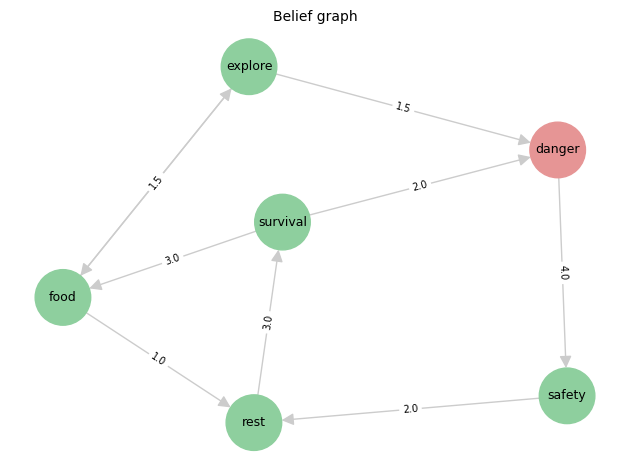

In [37]:
if __name__ == "__main__":
    G = build_belief_graph()
    draw_graph(G)